In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

IMAGES = Path("../output/figures")
IMAGES.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"]=(10,5)
plt.rcParams["axes.titlesize"]=13
plt.rcParams["axes.titleweight"]="bold"
plt.rcParams["figure.figsize"] = (10,5)

In [2]:
benchmark = pd.read_csv("../models/12473657/benchmark.csv")

In [3]:
benchmark.columns

Index(['model', 'accuracy_day', 'balanced_accuracy_day', 'precision_day',
       'recall_day', 'f1_day', 'train_time_day', 'top5_accuracy_day',
       'accuracy_tang', 'balanced_accuracy_tang', 'precision_tang',
       'recall_tang', 'f1_tang', 'train_time_tang', 'top5_accuracy_tang'],
      dtype='object')

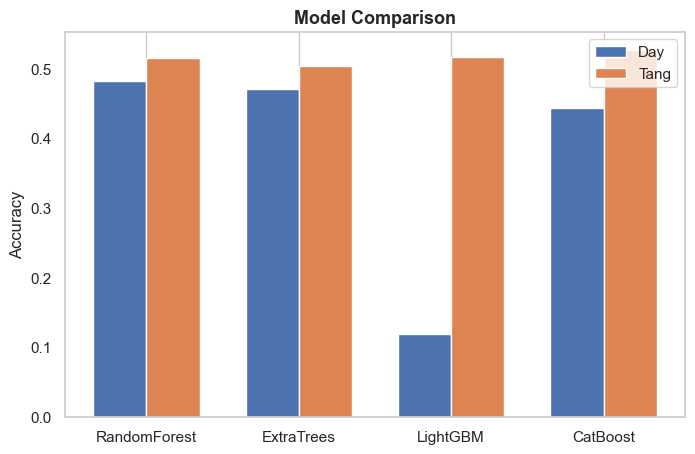

In [4]:
plt.figure(figsize=(8,5))

x = range(len(benchmark))

width = 0.35

plt.bar(
    [i - width/2 for i in x],
    benchmark["accuracy_day"],
    width=width,
    label="Day",
)

plt.bar(
    [i + width/2 for i in x],
    benchmark["accuracy_tang"],
    width=width,
    label="Tang",
)

plt.xticks(x, benchmark["model"])

plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.legend()

plt.grid(axis="y")

plt.show()

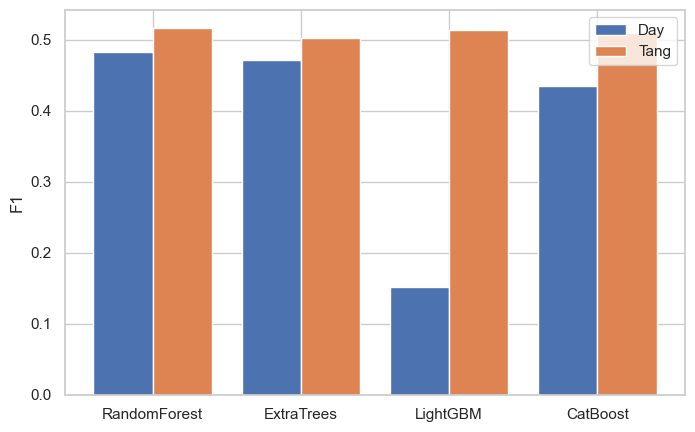

In [5]:
plt.figure(figsize=(8,5))

plt.bar(
    [i-0.2 for i in range(len(benchmark))],
    benchmark["f1_day"],
    width=0.4,
    label="Day",
)

plt.bar(
    [i+0.2 for i in range(len(benchmark))],
    benchmark["f1_tang"],
    width=0.4,
    label="Tang",
)

plt.xticks(range(len(benchmark)), benchmark["model"])

plt.ylabel("F1")

plt.legend()

plt.show()

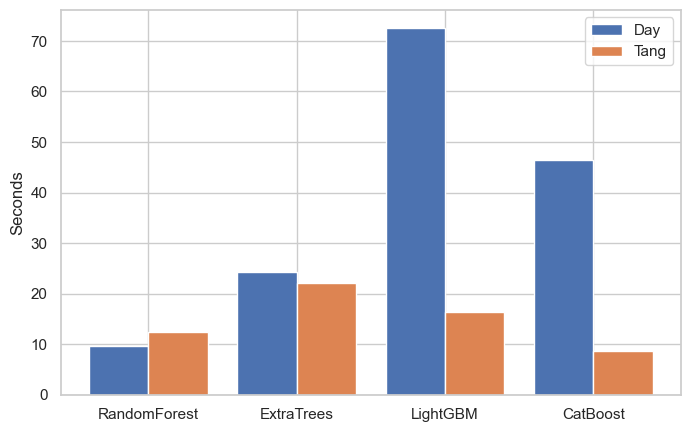

In [6]:
plt.figure(figsize=(8,5))

plt.bar(
    [i-0.2 for i in range(len(benchmark))],
    benchmark["train_time_day"],
    width=0.4,
    label="Day",
)

plt.bar(
    [i+0.2 for i in range(len(benchmark))],
    benchmark["train_time_tang"],
    width=0.4,
    label="Tang",
)

plt.xticks(range(len(benchmark)), benchmark["model"])

plt.ylabel("Seconds")

plt.legend()

plt.show()

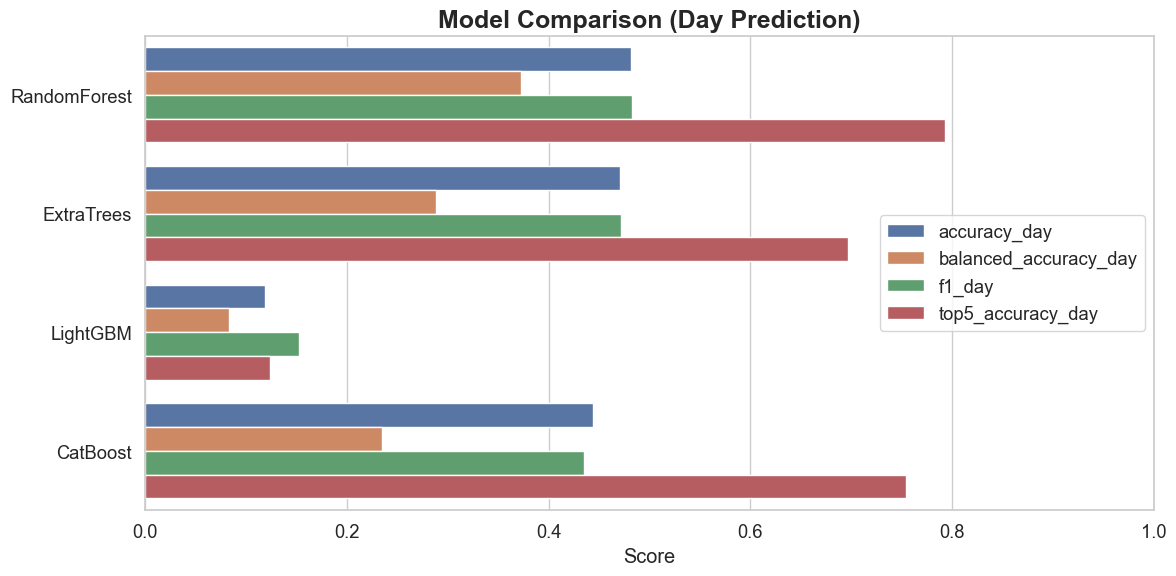

In [7]:
sns.set_theme(style="whitegrid", font_scale=1.2)

df = pd.read_csv("../models/12473657/benchmark.csv")

metrics = [
    "accuracy_day",
    "balanced_accuracy_day",
    "f1_day",
    "top5_accuracy_day"
]

plot_df = (
    df[["model"] + metrics]
    .melt(
        id_vars="model",
        var_name="Metric",
        value_name="Score"
    )
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=plot_df,
    x="Score",
    y="model",
    hue="Metric"
)

plt.xlim(0,1)

plt.title(
    "Model Comparison (Day Prediction)",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Score")
plt.ylabel("")

plt.legend(
    title=""
)

plt.tight_layout()
plt.show()

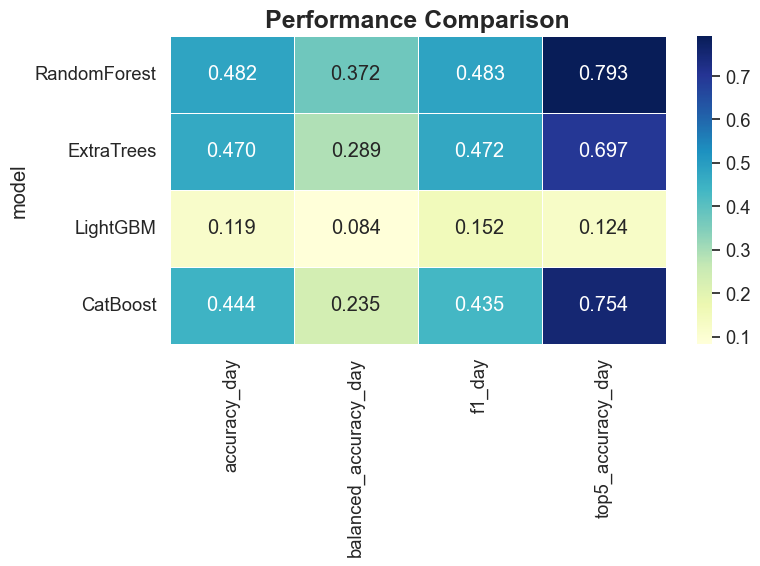

In [8]:
score = (
    df.set_index("model")[
        [
            "accuracy_day",
            "balanced_accuracy_day",
            "f1_day",
            "top5_accuracy_day",
        ]
    ]
)

plt.figure(figsize=(8,4))

sns.heatmap(
    score,
    annot=True,
    cmap="YlGnBu",
    fmt=".3f",
    linewidths=.5
)

plt.title(
    "Performance Comparison",
    fontsize=18,
    weight="bold"
)

plt.show()